In [26]:
using JLD2
using Printf
using Plots


In [27]:


function load_data(directory::String=joinpath(@__DIR__, "data"))
    # Keys will be the cutoff (Float64), and values will be the data dictionaries.
    all_data = Dict{Float64, Dict{String, Any}}()
    
    # We loop from 4 to 16, just like the HPC array
    powers = 4:16
    
    for p in powers
        cutoff_val = 10.0^(-p)
        cutoff_str = @sprintf("%.0e", cutoff_val)
        filename = joinpath(directory, "data_$(cutoff_str).jld2")
        
        if isfile(filename)
            println("Loading: $filename")
            # `load` automatically reads the JLD2 file into a Dict{String, Any}
            data = load(filename)
            all_data[cutoff_val] = data
        else
            @warn "File not found, skipping: $filename"
        end
    end
    
    return all_data
end



load_data (generic function with 2 methods)

In [28]:

data_dict = load_data(joinpath(@__DIR__, "data"))

println("\nSuccessfully loaded data for $(length(data_dict)) cutoffs.")

# 2. How to access specific data
# Let's say we want to look at the data for the 1e-16 cutoff
target_cutoff = 1e-16

if haskey(data_dict, target_cutoff)
    println("\n--- Extracting variables for EPS = $target_cutoff ---")
    
    target_data = data_dict[target_cutoff]
    
    # Extracting the arrays exactly as you requested
    avg_matrix   = target_data["avg_matrix"]     # Average bond dimensions
    err_matrix   = target_data["err_matrix"]     # Standard deviations
    N_range      = target_data["N_range"]        # System sizes (x-axis)
    sigma_values = target_data["sigma_values"]   # Disorder strengths
    vn_avg       = target_data["vn_avg"]         # Von Neumann entropy
    s05_avg      = target_data["s05_avg"]        # Renyi alpha = 0.5
    s0_avg       = target_data["s0_avg"]         # Renyi alpha = 0
    spectra_avg  = target_data["spectra_avg"]    # 3D Schmidt spectrum
    
    println("N_range: ", N_range)
    println("sigma_values: ", sigma_values)
    println("Size of avg_matrix: ", size(avg_matrix))
    println("Size of spectra_avg: ", size(spectra_avg))
    
    # Example: Get the average bond dimension for the 3rd N value and 2nd sigma value
    example_bd = avg_matrix[3, 2]
    println("\nExample: Average Bond Dimension at N=$(N_range[3]), sigma=$(sigma_values[2]) is $example_bd")
end

Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-04.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-05.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-06.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-07.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-08.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-09.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-10.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data\data_1e-11.jld2
Loading: c:\Users\Ethan\OneDrive - University of Bristol\Labs\Y4 Labs\A_Ethan_code\A_Sigmas\data

In [29]:
function plot_bond_dimensions(data_dict; selected_sigmas=nothing)
    plt_array = []
    
    # Sort cutoffs to plot them in a logical order
    cutoffs = sort(collect(keys(data_dict)), rev=true)
    
    for cutoff in cutoffs
        target_data = data_dict[cutoff]
        avg_matrix   = target_data["avg_matrix"]
        N_range      = target_data["N_range"]
        sigma_values = target_data["sigma_values"]
        
        p = plot(
            title="EPS = $cutoff", 
            xlabel="System Size N", 
            ylabel="Bond Dimension",
            legend=:topleft
        )
        
        # Loop through each sigma value and its corresponding column index (j)
        for (j, sig) in enumerate(sigma_values)
            # If selected_sigmas is provided, skip any sigma not in our list
            if selected_sigmas !== nothing && !(sig in selected_sigmas)
                continue
            end
            
            # Plot the line for the valid sigma
            plot!(p, N_range, avg_matrix[:, j], label="σ = $sig")
        end
        
        push!(plt_array, p)
    end
    
    n_plots = length(plt_array)
    cols = 4
    rows = ceil(Int, n_plots / cols)
    
    final_plot = plot(
        plt_array..., 
        layout=(rows, cols), 
        size=(400 * cols, 350 * rows), # Scales the overall image size dynamically
        plot_title="Bond Dimension vs System Size Across Truncations",
        margin=5Plots.mm
    )
    
    
    return final_plot
end



plot_bond_dimensions (generic function with 1 method)

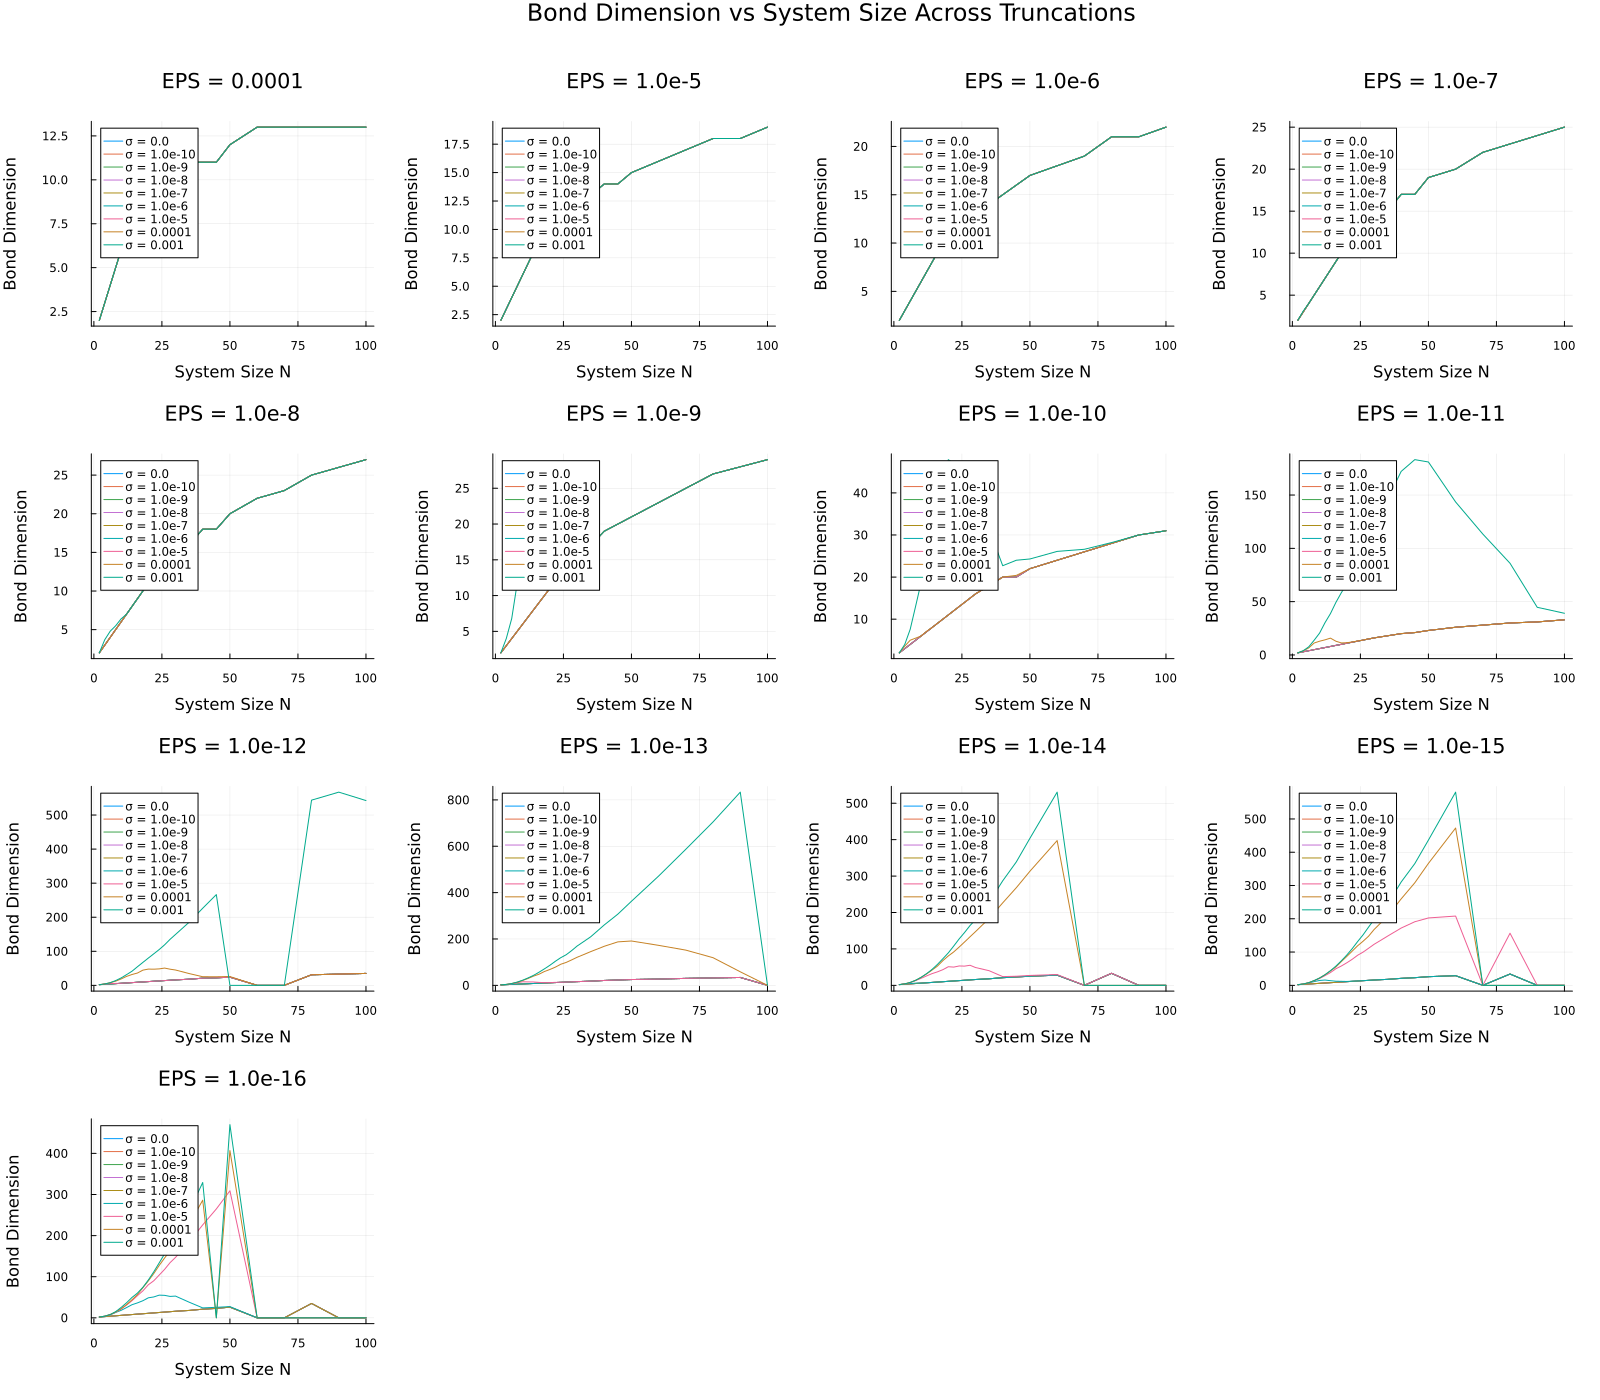

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\bond_dimension_grid.png"

In [30]:

p = plot_bond_dimensions(data_dict)
display(p)
savefig(p, "bond_dimension_grid.png")

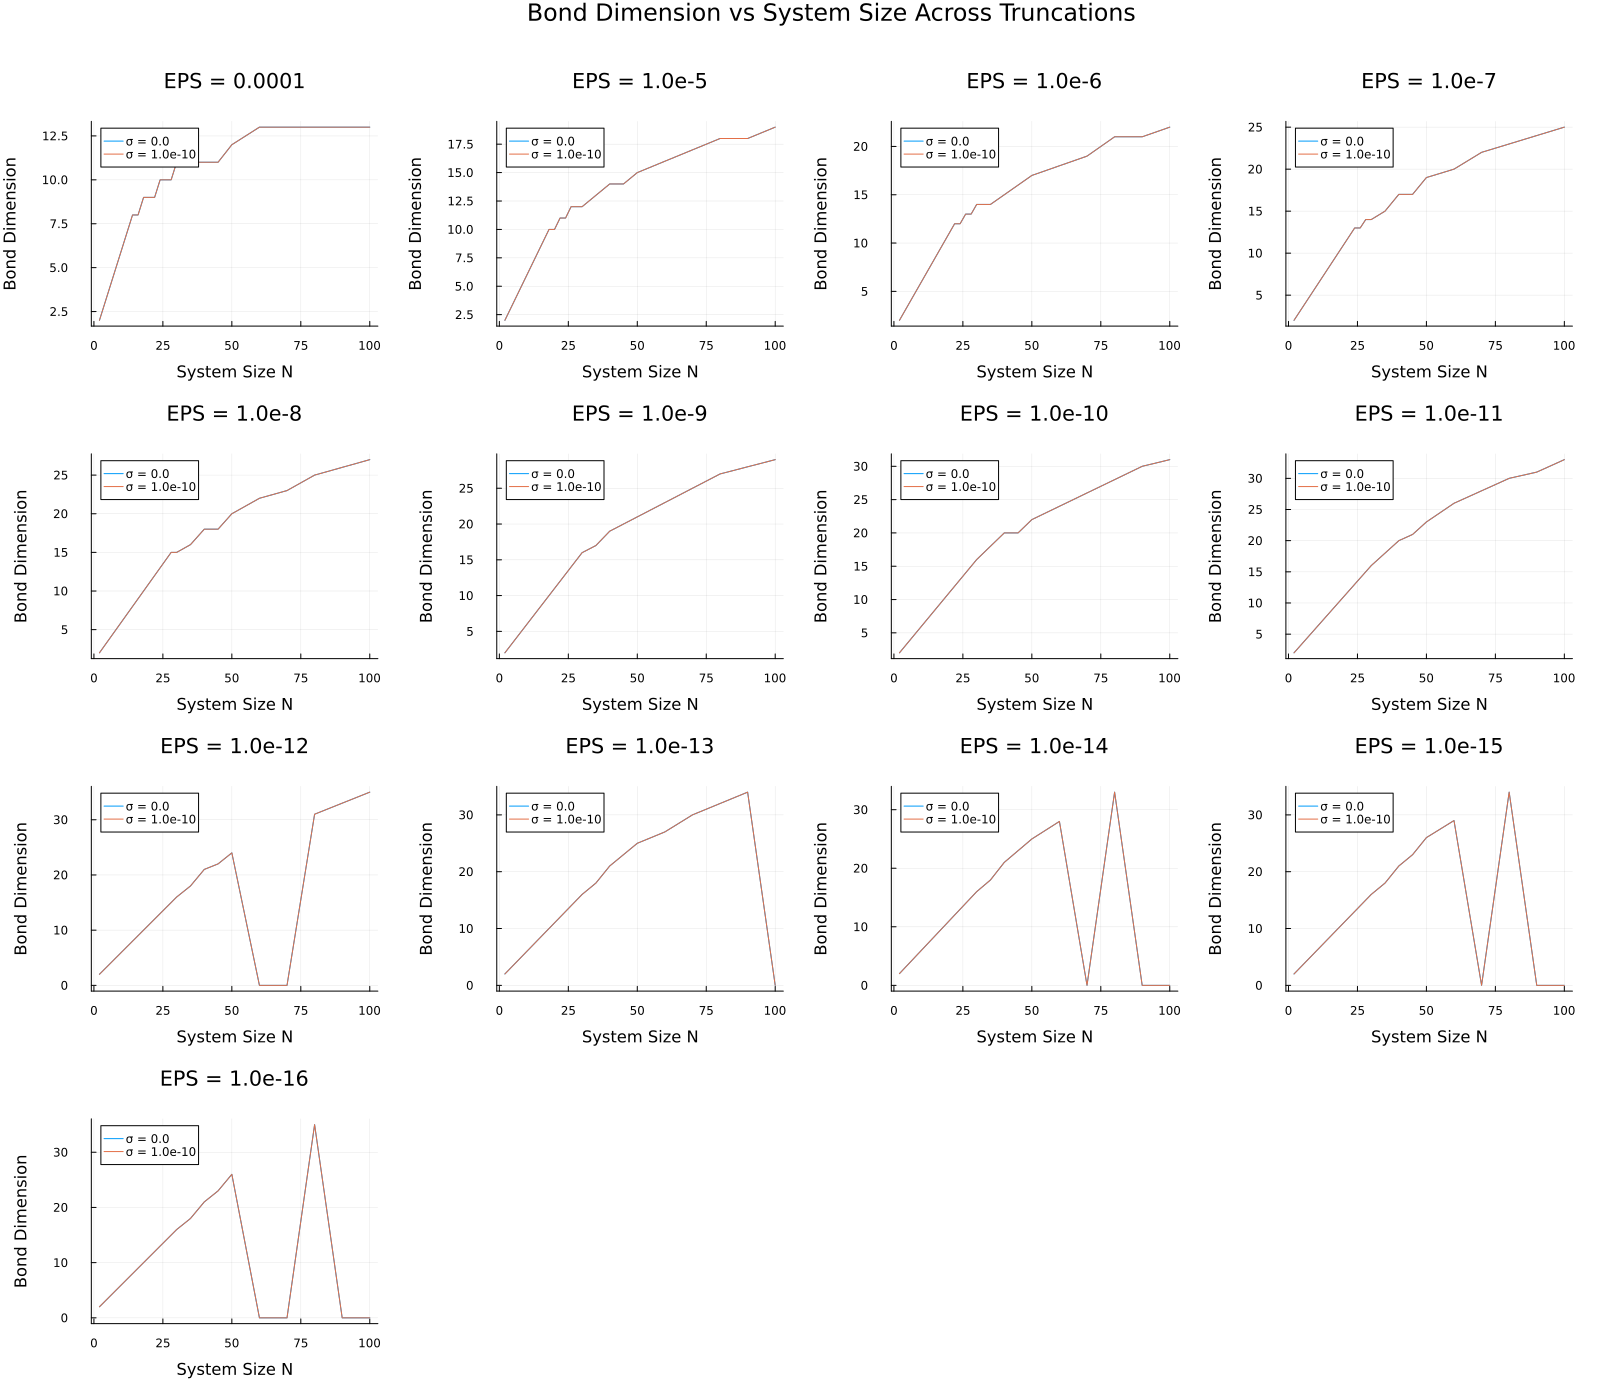

"c:\\Users\\Ethan\\OneDrive - University of Bristol\\Labs\\Y4 Labs\\A_Ethan_code\\A_Sigmas\\bond_dimension_grid_.png"

In [31]:

my_sigmas = [0.0, 1.0e-10] 
p_selected = plot_bond_dimensions(data_dict, selected_sigmas=my_sigmas)
display(p_selected)
savefig(p_selected, "bond_dimension_grid_.png")